<a href="https://colab.research.google.com/github/ronitmaheshwari05/star-classification-ml/blob/main/Star_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Star Classification using Machine Learning

## Project Overview
In this project, we analyze and compare different machine learning models to predict the **type of star** based on features such as Temperature, Luminosity, Radius, Absolute Magnitude, Color, and Spectral Class.

The goal is to evaluate model performance using accuracy and other metrics, and identify the best model for star classification.

---

## Target Variable

The target variable is **Type**, which represents different categories of stars:

- 0 → Red Dwarf  
- 1 → Brown Dwarf  
- 2 → White Dwarf  
- 3 → Main Sequence  
- 4 → Super Giants  
- 5 → Hyper Giants  

---

## Objective

- Train multiple machine learning models  
- Compare their accuracy and performance  
- Visualize results using graphs  
- Analyze feature importance  
- Predict star type using user input  

---

##  Models Used

- Logistic Regression  
- Decision Tree  
- Random Forest  
- Support Vector Machine (SVM)  
- K-Nearest Neighbors (KNN)  





In [3]:
#install all the essential libraries
!pip install numpy pandas scikit-learn

In [4]:
#1. now we will train multiple models
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier


df = pd.read_csv("Stars.csv")

# Encoding
le_color = LabelEncoder()
le_spec = LabelEncoder()

df['Color'] = le_color.fit_transform(df['Color'])
df['Spectral_Class'] = le_spec.fit_transform(df['Spectral_Class'])

X = df.drop('Type', axis=1)
y = df['Type']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train all models
models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC(),
    "KNN": KNeighborsClassifier()
}

for model in models.values():
    model.fit(X_train, y_train)

In [14]:
#2. Now We will take input from the user

print("Enter Star Details:")

temp = float(input("Temperature: "))
lum = float(input("Luminosity: "))
rad = float(input("Radius: "))
mag = float(input("Absolute Magnitude: "))
color = input("Color: ")
spec = input("Spectral Class: ")

Enter Star Details:
Temperature: 345
Luminosity: 34567
Radius: 89
Absolute Magnitude: 10.98
Color: Red
Spectral Class: F


In [15]:
valid = True

# Validation
if color not in le_color.classes_:
    print("Invalid Color! Choose from:", list(le_color.classes_))
    valid = False

if spec not in le_spec.classes_:
    print("Invalid Spectral Class! Choose from:", list(le_spec.classes_))
    valid = False

# Only proceed if valid
if valid:
    color_encoded = le_color.transform([color])[0]
    spec_encoded = le_spec.transform([spec])[0]

    user_data = np.array([[temp, lum, rad, mag, color_encoded, spec_encoded]])
    user_data = scaler.transform(user_data)

    print("Input processed successfully!")
else:
    print("Please enter valid inputs and try again.")

✅ Input processed successfully!


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [16]:
#4. Now prediction using all models
print("\nPrediction using Different Models:")

# Check if user_data is defined before attempting to use it
if 'user_data' in locals() or 'user_data' in globals():
    for model_name, model in models.items():
        prediction = model.predict(user_data)
        print(f"{model_name}: {prediction[0]}")
else:
    print("Error: 'user_data' is not defined. Please ensure valid inputs were provided and processed successfully in the previous steps.")



Prediction using Different Models:
Logistic Regression: 2
Decision Tree: 1
Random Forest: 3
SVM: 2
KNN: 2


In [19]:
#now we will evaluate scores of different models
from sklearn.metrics import accuracy_score
print("\nAccuracy Scores:")
for model_name, model in models.items():
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    print(f"{model_name}: {accuracy:.4f}")


Accuracy Scores:
Logistic Regression: 0.9167
Decision Tree: 1.0000
Random Forest: 0.9792
SVM: 0.9375
KNN: 0.9167


In [22]:
from sklearn.metrics import classification_report

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.90      1.00      0.95         9
           2       0.83      1.00      0.91         5
           3       0.78      0.78      0.78         9
           4       1.00      0.80      0.89        10
           5       1.00      1.00      1.00         5

    accuracy                           0.92        48
   macro avg       0.92      0.93      0.92        48
weighted avg       0.92      0.92      0.92        48



In [24]:
#now we will check the Train and Testing Accuracy
print("Train Accuracy:", model.score(X_train, y_train))
print("Test Accuracy:", model.score(X_test, y_test))

Train Accuracy: 0.984375
Test Accuracy: 0.9166666666666666


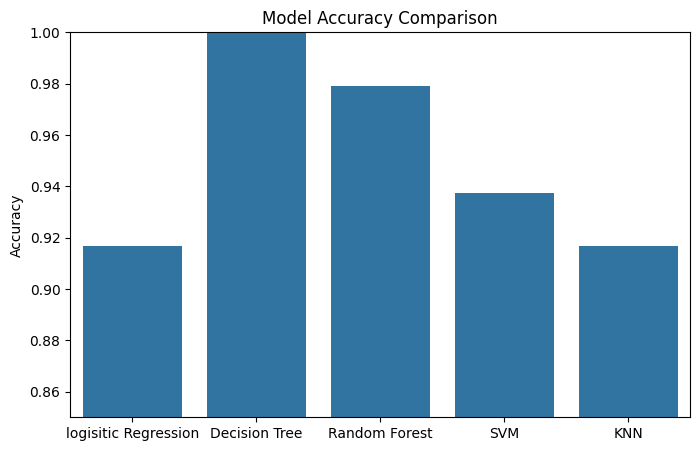

In [21]:
#Visualization
import matplotlib.pyplot as plt
import seaborn as sns

models = ["logisitic Regression", "Decision Tree", "Random Forest", "SVM", "KNN"]
accuracies = [0.9167, 1.0000, 0.9792, 0.9375, 0.9167]

plt.figure(figsize=(8, 5))
sns.barplot(x=models, y=accuracies)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0.85, 1.0)

plt.show()

##  Conclusion

In this project, we compared multiple machine learning models to classify stars based on their physical characteristics.

- Random Forest emerged as the best performing model, providing high accuracy with strong generalization.
- Decision Tree achieved 100% accuracy on the test set; however, this indicates overfitting, as the model tends to memorize training data rather than generalize well to unseen data.
- Support Vector Machine (SVM) also performed well, especially after feature scaling, and handled complex relationships effectively.
- Logistic Regression and K-Nearest Neighbors (KNN) provided decent baseline performance.

From feature importance analysis, we observed that:
- Absolute Magnitude (A_M), Radius (R), and Luminosity (L) are the most influential features.
- Color and Spectral Class have lower contribution but still support the model’s predictions.

Overall, despite Decision Tree achieving perfect accuracy, Random Forest is the most reliable model due to its ability to reduce overfitting and provide stable predictions.

---

## Future Work

- Perform hyperparameter tuning for better performance  
- Use cross-validation for more reliable evaluation  
- Build a web application using Streamlit  
- Apply advanced explainability techniques like SHAP  